# SI'26 – Week 1: Urdu OCR Dataset Collection
**Author: Qandeel Asim**
**Student ID: 2023-BS-AI-037**

---

## What this notebook does

This notebook builds a labeled Urdu OCR dataset from **six sources**:

| # | Source | Method |
|---|--------|--------|
| 1 | UTRSet-Real | Download public research dataset |
| 2 | Synthetic Urdu text | Render text with PIL + Noto Nastaliq Urdu font |
| 3 | Augmented images | Rotate / blur / brighten the synthetic images |
| 4 | Books | Synthetic book-page-style images (or real photos — optional) |
| 5 | Signboards | Synthetic signboard-style images (or real photos — optional) |
| 6 | Newspaper | Manual screenshots + automatic OCR transcription |

Everything writes into one master file: `data/labels.csv`, with columns
`image, text, source, split`. At the end the notebook validates every row,
creates an 80/20 train/test split, and prints dataset statistics.

Run the cells **in order, top to bottom** — later cells depend on variables
and functions defined earlier.

## 0. Setup — Install & Import

In [1]:
# Install all required libraries
!pip install Pillow arabic-reshaper python-bidi gdown matplotlib easyocr -q
print("Installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 33.7 MB/s eta 0:00:00
Installed.


In [2]:
# Standard library imports
import csv
import os
import random
import shutil
import textwrap
import zipfile
from pathlib import Path

# Image processing
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance

# Urdu text rendering (shaping + right-to-left order)
import arabic_reshaper
from bidi.algorithm import get_display

# Visualization
import matplotlib.pyplot as plt

# Fix random seed so results are reproducible
random.seed(42)
print("Imports complete.")

Imports complete.


## 1. Folder Structure

We create one folder per image category, plus the master label files.
This makes it easy to track how many images come from each source.

In [3]:
# Category folders
FOLDERS = [
    'data/raw/newspaper',
    'data/raw/books',
    'data/raw/signboards',
    'data/raw/synthetic',
    'data/raw/augmented',
    'data/raw/other',
]

LABELS_CSV = 'data/labels.csv'   # master label file
TRAIN_CSV  = 'data/train.csv'    # 80% split
TEST_CSV   = 'data/test.csv'     # 20% split

for folder in FOLDERS:
    os.makedirs(folder, exist_ok=True)
    print(f"  Created: {folder}")

print("\nFolder structure ready.")

  Created: data/raw/newspaper
  Created: data/raw/books
  Created: data/raw/signboards
  Created: data/raw/synthetic
  Created: data/raw/augmented
  Created: data/raw/other

Folder structure ready.


## 2. Helper Functions

### 2a. labels.csv writer
This function merges new rows with existing rows, so running any source
cell multiple times never creates duplicates or overwrites earlier work.

In [4]:
def append_to_labels_csv(new_rows, labels_csv=LABELS_CSV):
    """
    Append new_rows to labels_csv, preserving any rows already present.
    Each row must be a dict with keys: image, text, source, split.
    """
    existing_rows = []
    if os.path.exists(labels_csv):
        with open(labels_csv, 'r', encoding='utf-8') as f:
            existing_rows = list(csv.DictReader(f))

    # Avoid duplicate rows if a cell is re-run
    existing_images = {r['image'] for r in existing_rows}
    new_rows = [r for r in new_rows if r['image'] not in existing_images]

    all_rows = existing_rows + new_rows

    os.makedirs(os.path.dirname(labels_csv), exist_ok=True)
    with open(labels_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['image', 'text', 'source', 'split'])
        writer.writeheader()
        writer.writerows(all_rows)

    print(f"  labels.csv: {len(all_rows)} total entries (+{len(new_rows)} new).")
    return all_rows

### 2b. Image quality validator

In [5]:
def is_valid_image(path):
    """
    Returns True only if the file:
      - exists on disk
      - can be opened by Pillow without error
      - is not a completely blank (all-white or all-black) image
    """
    if not os.path.exists(path):
        return False
    try:
        img = Image.open(path).convert('L')   # convert to grayscale
        pixels = list(img.getdata())
        unique = set(pixels)
        if len(unique) <= 2:                   # blank image — only 1 or 2 pixel values
            return False
        return True
    except Exception:
        return False

## 3. Source 1 — UTRSet-Real (Public Research Dataset)

**UTRSet-Real** is a printed Urdu text-line dataset published for OCR
research. We download it once, then copy a subset of samples into
`data/raw/other/`.

In [6]:
# ── Configuration ──────────────────────────────────────────────────────────
GDRIVE_FILE_ID = "1mABkzaWe1hLikXCaM5nmLsBCWtxvDE7T"
DOWNLOAD_DIR   = "utrset_real_download"
ZIP_PATH       = os.path.join(DOWNLOAD_DIR, "utrset_real.zip")
EXTRACT_DIR    = os.path.join(DOWNLOAD_DIR, "extracted")
UTRSET_OUT_DIR = "data/raw/other"
N_SAMPLES      = 60   # number of UTRSet-Real samples to include

In [7]:
def download_utrset():
    """Download UTRSet-Real ZIP from Google Drive (skips if already downloaded)."""
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    if os.path.exists(ZIP_PATH):
        print(f"Already downloaded: {ZIP_PATH}")
        return

    print("Downloading UTRSet-Real from Google Drive (may take a few minutes)...")
    import gdown
    gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    # Google Drive sometimes returns an HTML warning page instead of the real file
    if not os.path.exists(ZIP_PATH) or os.path.getsize(ZIP_PATH) < 1024:
        raise RuntimeError(
            "Download failed or returned an HTML warning page.\n"
            "Open the link manually in your browser and download it:\n"
            f"  https://drive.google.com/file/d/{GDRIVE_FILE_ID}/view"
        )


def extract_utrset():
    """Extract the downloaded ZIP (skips if already extracted)."""
    if os.path.exists(EXTRACT_DIR) and os.listdir(EXTRACT_DIR):
        print(f"Already extracted: {EXTRACT_DIR}")
        return
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print("Extracting ZIP...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Extraction complete.")


def find_gt_file(root):
    """Walk the extracted folder tree and return any ground-truth text files found."""
    candidates = []
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if fname.lower() in ("gt.txt", "ground_truth.txt", "labels.txt"):
                candidates.append(os.path.join(dirpath, fname))
    return candidates


def find_images(root):
    """Return all PNG/JPG/JPEG paths under root."""
    images = []
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                images.append(os.path.join(dirpath, fname))
    return images

In [8]:
def collect_utrset_samples():
    """
    Full pipeline: download -> extract -> parse gt.txt -> copy N_SAMPLES pairs.
    Returns a list of row dicts for labels.csv.
    """
    download_utrset()
    extract_utrset()

    gt_files = find_gt_file(EXTRACT_DIR)
    images   = find_images(EXTRACT_DIR)
    print(f"Found {len(gt_files)} ground-truth file(s), {len(images)} image(s) in archive.")

    os.makedirs(UTRSET_OUT_DIR, exist_ok=True)
    new_rows = []

    if not gt_files:
        print("No ground-truth file found -- skipping UTRSet-Real.")
        return new_rows

    gt_path = gt_files[0]
    print(f"Parsing ground truth: {gt_path}")
    with open(gt_path, "r", encoding="utf-8") as f:
        lines = [l.strip() for l in f if l.strip()]

    gt_dir = os.path.dirname(gt_path)
    for line in lines:
        if len(new_rows) >= N_SAMPLES:
            break

        # gt.txt format: "<img_relative_path>\t<text>" or "<img_relative_path> <text>"
        if "\t" in line:
            img_rel, text = line.split("\t", 1)
        elif " " in line:
            img_rel, text = line.split(" ", 1)
        else:
            continue

        src = os.path.join(gt_dir, img_rel)
        if not os.path.exists(src):
            continue

        ext      = os.path.splitext(src)[1]
        dst_name = f"utrset_{len(new_rows)+1:03d}{ext}"
        dst      = os.path.join(UTRSET_OUT_DIR, dst_name)
        shutil.copy2(src, dst)

        if is_valid_image(dst):
            new_rows.append({
                'image': dst, 'text': text.strip(),
                'source': 'utrset_real', 'split': ''
            })

    print(f"Copied {len(new_rows)} valid UTRSet-Real samples -> {UTRSET_OUT_DIR}")
    return new_rows

In [9]:
utrset_rows = collect_utrset_samples()
append_to_labels_csv(utrset_rows)

Downloading...
From (original): https://drive.google.com/uc?id=1mABkzaWe1hLikXCaM5nmLsBCWtxvDE7T
From (redirected): https://drive.google.com/uc?id=1mABkzaWe1hLikXCaM5nmLsBCWtxvDE7T&confirm=t&uuid=8dd82cdc-7d03-482c-b585-c4afcae1f060
To: /content/utrset_real_download/utrset_real.zip
100%|██████████| 212M/212M [00:01<00:00, 142MB/s]


Extracting ZIP...
Extraction complete.
Found 2 ground-truth file(s), 22322 image(s) in archive.
Parsing ground truth: utrset_real_download/extracted/UTRSet-Real/train/gt.txt
Copied 60 valid UTRSet-Real samples -> data/raw/other
  labels.csv: 60 total entries (+60 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'اندراج و تحریر شرعاً صرف مستحب اور پسندیدہ ہے وہ واجب نہیں کہ کسی شرعی',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'اور ہندوستان کی مسلم ریاستوں میں اس پر کم و بیش عمل درآمد بھی ہے، جہاں تک جبری',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'بلکہ اس کے نزدیک وہ پسندیدہ اور مستحسن بھی ہے، عملی پہلوکے لحاظ سے اسلامی سلطنتوں',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'جہاں تک پہلی صورت کاتعلق ہے، شریعت اسلامیہ کی رو سے اس پر اعتراض جائز نہیں،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'ہے، اس لیے اس کولازمی طورپر جاری کردیاجائے، اس کانام جبر ی اندراج ہے،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'مقدمات سے نجات مل سکتی ہے، نکاح کے ثبوت اورک دین مہر کے تعین میں سہ

## 4. Source 2 — Synthetic Urdu Images

Urdu sentences are rendered into images using the **Noto Nastaliq Urdu**
font. `arabic_reshaper` joins letters into their correct connected forms;
`python-bidi` handles right-to-left direction.

We use **four visual styles** (white, cream, light gray, small/signboard-like)
to add variety.

In [10]:
# ── 50 Urdu sentences covering different topics ──────────────────────────
URDU_TEXTS = [
    # Everyday / motivational
    "پاکستان زندہ باد",
    "محنت کامیابی کی کنجی ہے",
    "علم انسان کو روشنی دیتا ہے",
    "وقت کی قدر کرنی چاہیے",
    "صحت سب سے بڑی نعمت ہے",
    "دوستی ایک قیمتی رشتہ ہے",
    "محنت کبھی رائیگاں نہیں جاتی",
    "ہمت مرداں مدد خدا",
    "اتحاد میں برکت ہے",
    "سچائی بہترین پالیسی ہے",
    # Geography / general knowledge
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "لاہور پاکستان کا دل ہے",
    "اسلام آباد پاکستان کا دارالحکومت ہے",
    "دریائے سندھ پاکستان کا سب سے بڑا دریا ہے",
    "کے ٹو دنیا کی دوسری بلند ترین چوٹی ہے",
    # Education / science
    "تعلیم ہر انسان کا حق ہے",
    "سائنس نے دنیا کو بدل دیا ہے",
    "ریاضی ایک مشکل لیکن دلچسپ مضمون ہے",
    "آرٹیفیشل انٹیلیجنس مستقبل کی ٹیکنالوجی ہے",
    "کمپیوٹر نے انسانی زندگی آسان کر دی ہے",
    # News / current affairs style
    "حکومت نے نئی تعلیمی پالیسی کا اعلان کیا",
    "پاکستان اور چین کے درمیان تجارت بڑھ رہی ہے",
    "ملک میں بارشوں کا نیا سلسلہ شروع ہو گیا",
    "اسٹاک مارکیٹ میں آج تیزی کا رجحان رہا",
    "نئے منصوبے کی بنیاد رکھ دی گئی",
    # Poetry / literature
    "شعر و ادب کا سفر جاری ہے",
    "اردو ادب کی تاریخ بہت پرانی ہے",
    "غالب اردو شاعری کے عظیم شاعر تھے",
    "اقبال کا کلام آج بھی متعلق ہے",
    "فیض احمد فیض نے انقلابی شاعری کی",
    # Health / food
    "آج کا موسم خوشگوار ہے",
    "پھل اور سبزیاں صحت کے لیے ضروری ہیں",
    "صاف پانی پینا صحت کے لیے اہم ہے",
    "ورزش کو روزانہ کا معمول بنائیں",
    "متوازن غذا لمبی عمر کی ضمانت ہے",
    # Technology
    "موبائل فون نے دنیا کو ایک گاؤں بنا دیا",
    "انٹرنیٹ نے معلومات تک رسائی آسان کی",
    "الیکٹرک گاڑیاں مستقبل کی سواری ہیں",
    "سولر انرجی ماحول دوست توانائی ہے",
    "ڈیجیٹل ادائیگی تیزی سے مقبول ہو رہی ہے",
    # Religion / culture
    "رمضان مسلمانوں کا مقدس مہینہ ہے",
    "عید الفطر خوشیوں کا تہوار ہے",
    "قرآن مجید مسلمانوں کی مقدس کتاب ہے",
    "پاکستان کا قیام چودہ اگست انیس سو سینتالیس کو ہوا",
    "بسم اللہ الرحمٰن الرحیم",
    # Short phrases / signboard style
    "داخلہ ممنوع",
    "خطرہ ہائی وولٹیج",
    "آگے سڑک بند ہے",
    "یہاں پارکنگ منع ہے",
    "براہ کرم خاموش رہیں",
    "شکریہ",
]

print(f"Total Urdu sentences: {len(URDU_TEXTS)}")

Total Urdu sentences: 51


In [11]:
# Download Noto Nastaliq Urdu font from the Google Fonts repo
FONT_PATH = "NotoNastaliqUrdu-Regular.ttf"

if not os.path.exists(FONT_PATH):
    import urllib.request
    font_url = (
        "https://raw.githubusercontent.com/google/fonts/main/ofl/"
        "notonastaliqurdu/NotoNastaliqUrdu%5Bwght%5D.ttf"
    )
    try:
        urllib.request.urlretrieve(font_url, FONT_PATH)
        print(f"Font downloaded: {FONT_PATH}")
    except Exception as e:
        print(f"Auto-download failed ({e}).")
        print("Manually download 'Noto Nastaliq Urdu' from fonts.google.com")
        print(f"and upload it to your Colab file panel as: {FONT_PATH}")

font_small  = ImageFont.truetype(FONT_PATH, 28)   # small text -- signboard style
font_medium = ImageFont.truetype(FONT_PATH, 36)   # default
font_large  = ImageFont.truetype(FONT_PATH, 48)   # large -- book/newspaper headline
print("Fonts loaded.")

Font downloaded: NotoNastaliqUrdu-Regular.ttf
Fonts loaded.


In [12]:
# Visual style configurations for synthetic images
# Each style dict defines: background color, text color, font size, padding
STYLES = [
    {"bg": (255, 255, 255), "fg": (0,   0,   0),   "font": "medium", "pad": 20},  # white
    {"bg": (255, 251, 230), "fg": (30,  30,  30),  "font": "medium", "pad": 24},  # cream
    {"bg": (240, 240, 240), "fg": (10,  10,  80),  "font": "large",  "pad": 30},  # light gray, blue text
    {"bg": (255, 255, 255), "fg": (0,   0,   0),   "font": "small",  "pad": 14},  # white, small (signboard)
]

FONT_MAP = {
    "small":  font_small,
    "medium": font_medium,
    "large":  font_large,
}


def render_urdu_image(text, style):
    """
    Render a single Urdu text string into a PIL Image using the given style dict.
    Returns the PIL Image object.
    """
    font_obj   = FONT_MAP[style["font"]]
    pad        = style["pad"]
    bg_color   = style["bg"]
    text_color = style["fg"]

    # Reshape Urdu characters and apply RTL direction
    reshaped  = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)

    # Measure text size on a throwaway canvas
    dummy = ImageDraw.Draw(Image.new("RGB", (10, 10)))
    bbox  = dummy.textbbox((0, 0), bidi_text, font=font_obj)
    w     = bbox[2] - bbox[0]
    h     = bbox[3] - bbox[1]

    # Create actual image with padding
    img  = Image.new("RGB", (w + pad * 2, h + pad * 2), color=bg_color)
    draw = ImageDraw.Draw(img)
    draw.text((pad - bbox[0], pad - bbox[1]), bidi_text, fill=text_color, font=font_obj)
    return img

In [13]:
def generate_synthetic_images():
    """
    Render all URDU_TEXTS in all STYLES and save to data/raw/synthetic/.
    Returns a list of label row dicts.
    """
    rows  = []
    count = 0

    for i, text in enumerate(URDU_TEXTS):
        # Cycle through styles so each sentence gets a different look
        style     = STYLES[i % len(STYLES)]
        img       = render_urdu_image(text, style)
        save_path = f"data/raw/synthetic/urdu_{i+1:03d}.png"
        img.save(save_path)
        rows.append({
            'image': save_path, 'text': text,
            'source': 'synthetic', 'split': ''
        })
        count += 1

    print(f"Generated {count} synthetic images -> data/raw/synthetic/")
    return rows

synthetic_rows = generate_synthetic_images()
append_to_labels_csv(synthetic_rows)

Generated 51 synthetic images -> data/raw/synthetic/
  labels.csv: 111 total entries (+51 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'اندراج و تحریر شرعاً صرف مستحب اور پسندیدہ ہے وہ واجب نہیں کہ کسی شرعی',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'اور ہندوستان کی مسلم ریاستوں میں اس پر کم و بیش عمل درآمد بھی ہے، جہاں تک جبری',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'بلکہ اس کے نزدیک وہ پسندیدہ اور مستحسن بھی ہے، عملی پہلوکے لحاظ سے اسلامی سلطنتوں',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'جہاں تک پہلی صورت کاتعلق ہے، شریعت اسلامیہ کی رو سے اس پر اعتراض جائز نہیں،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'ہے، اس لیے اس کولازمی طورپر جاری کردیاجائے، اس کانام جبر ی اندراج ہے،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'مقدمات سے نجات مل سکتی ہے، نکاح کے ثبوت اورک دین مہر کے تعین میں سہ

## 5. Source 3 — Data Augmentation

Augmentation artificially increases dataset size and makes the model more
robust to real-world image quality (blur, rotation, brightness changes).

In [14]:
def augment_image(img):
    """
    Apply one random augmentation (rotation, blur, or brightness change).
    Returns (augmented_image, augmentation_type_string).
    """
    aug_type = random.choice(["rotation", "blur", "brightness"])

    if aug_type == "rotation":
        angle = random.uniform(-5, 5)
        aug_img = img.rotate(angle, expand=True, fillcolor=(255, 255, 255))
    elif aug_type == "blur":
        aug_img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))
    else:  # brightness
        enhancer = ImageEnhance.Brightness(img)
        aug_img = enhancer.enhance(random.uniform(0.7, 1.3))

    return aug_img, aug_type

In [15]:
def generate_augmented_images(source_rows, augments_per_image=2):
    """
    For each image in source_rows, create `augments_per_image` augmented variants.
    Saves them to data/raw/augmented/ and returns label row dicts.
    """
    rows  = []
    count = 0

    for row in source_rows:
        src_path = row['image']
        if not is_valid_image(src_path):
            continue

        img = Image.open(src_path)

        for j in range(augments_per_image):
            aug_img, aug_type = augment_image(img)
            save_path = (
                f"data/raw/augmented/"
                f"{Path(src_path).stem}_aug{j+1}_{aug_type}.png"
            )
            aug_img.save(save_path)
            rows.append({
                'image': save_path, 'text': row['text'],
                'source': f'augmented_{aug_type}', 'split': ''
            })
            count += 1

    print(f"Generated {count} augmented images -> data/raw/augmented/")
    return rows

# Augment the synthetic images (2 variants each -> 100 extra images)
aug_rows = generate_augmented_images(synthetic_rows, augments_per_image=2)
append_to_labels_csv(aug_rows)

Generated 102 augmented images -> data/raw/augmented/
  labels.csv: 213 total entries (+102 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'اندراج و تحریر شرعاً صرف مستحب اور پسندیدہ ہے وہ واجب نہیں کہ کسی شرعی',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'اور ہندوستان کی مسلم ریاستوں میں اس پر کم و بیش عمل درآمد بھی ہے، جہاں تک جبری',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'بلکہ اس کے نزدیک وہ پسندیدہ اور مستحسن بھی ہے، عملی پہلوکے لحاظ سے اسلامی سلطنتوں',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'جہاں تک پہلی صورت کاتعلق ہے، شریعت اسلامیہ کی رو سے اس پر اعتراض جائز نہیں،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'ہے، اس لیے اس کولازمی طورپر جاری کردیاجائے، اس کانام جبر ی اندراج ہے،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'مقدمات سے نجات مل سکتی ہے، نکاح کے ثبوت اورک دین مہر کے تعین میں سہ

## 6. Source 4 — Books (Synthetic Book-Page Images)

This fills the `data/raw/books/` folder with book-page-style Urdu images:
long paragraphs, off-white background, multi-line wrapped text, and a light
blur on some images to mimic a scanned page.

> **Have real book photos instead?** Skip to the optional
> **Section 6a — Real Photos (Books / Signboards / Newspaper)** near the end
> of the notebook, which extracts a ZIP of real photos into the correct
> folders. You can use synthetic images, real photos, or both.

In [16]:
BOOK_PARAGRAPHS = [
    "علم انسان کی سب سے بڑی دولت ہے۔ یہ ایک ایسا خزانہ ہے جو کبھی ختم نہیں ہوتا۔",
    "وقت کی قدر کرنے والے ہی زندگی میں کامیاب ہوتے ہیں۔ گزرا ہوا وقت کبھی واپس نہیں آتا۔",
    "محنت اور لگن سے انسان ہر مشکل کو آسان بنا سکتا ہے۔ یہی کامیابی کی اصل کنجی ہے۔",
    "کتابیں انسان کی بہترین دوست ہوتی ہیں۔ یہ ہمیں نئے جہانوں کی سیر کراتی ہیں۔",
    "اچھے اخلاق انسان کی سب سے بڑی پہچان ہوتے ہیں۔ یہ زندگی بھر کام آتے ہیں۔",
    "قوموں کی تعمیر میں تعلیم کا کردار سب سے اہم ہے۔ تعلیم یافتہ قومیں ہی ترقی کرتی ہیں۔",
    "صبر اور استقامت سے بڑے سے بڑے مسئلے کا حل نکل آتا ہے۔ ہمت نہیں ہارنی چاہیے۔",
    "دوستی ایک انمول رشتہ ہے جسے نبھانا ہر انسان کا فرض ہے۔ سچی دوستی مشکل وقت میں کام آتی ہے۔",
]


def render_book_image(text, width=800):
    """
    Render a long Urdu paragraph as a book-page-style image:
    wrapped across multiple lines, right-aligned, off-white background.
    Returns the PIL Image object.
    """
    bg_color = random.choice([(245, 240, 230), (250, 247, 240), (240, 234, 214)])
    text_color = (26, 26, 26)
    font_obj = font_medium

    reshaped_lines = []
    for line in textwrap.wrap(text, width=28):
        reshaped = arabic_reshaper.reshape(line)
        reshaped_lines.append(get_display(reshaped))

    line_height = 45
    height = 80 + line_height * len(reshaped_lines)

    img = Image.new("RGB", (width, height), color=bg_color)
    draw = ImageDraw.Draw(img)

    for i, line in enumerate(reshaped_lines):
        bbox = draw.textbbox((0, 0), line, font=font_obj)
        line_w = bbox[2] - bbox[0]
        x = width - 50 - line_w   # right-aligned, RTL style
        y = 40 + i * line_height
        draw.text((x, y), line, fill=text_color, font=font_obj)

    # Light blur on half the images to mimic a scanned page
    if random.random() < 0.5:
        img = img.filter(ImageFilter.GaussianBlur(radius=0.4))

    return img


def generate_book_images():
    """
    Render all BOOK_PARAGRAPHS into book-page-style images and
    save them to data/raw/books/. Returns a list of label row dicts.
    """
    rows = []
    count = 0

    for i, text in enumerate(BOOK_PARAGRAPHS):
        img = render_book_image(text)
        save_path = f"data/raw/books/book_{i+1:03d}.png"
        img.save(save_path)
        rows.append({
            'image': save_path, 'text': text,
            'source': 'books_synthetic', 'split': ''
        })
        count += 1

    print(f"Generated {count} book-page images -> data/raw/books/")
    return rows


book_rows = generate_book_images()
append_to_labels_csv(book_rows)

Generated 8 book-page images -> data/raw/books/
  labels.csv: 221 total entries (+8 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'اندراج و تحریر شرعاً صرف مستحب اور پسندیدہ ہے وہ واجب نہیں کہ کسی شرعی',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'اور ہندوستان کی مسلم ریاستوں میں اس پر کم و بیش عمل درآمد بھی ہے، جہاں تک جبری',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'بلکہ اس کے نزدیک وہ پسندیدہ اور مستحسن بھی ہے، عملی پہلوکے لحاظ سے اسلامی سلطنتوں',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'جہاں تک پہلی صورت کاتعلق ہے، شریعت اسلامیہ کی رو سے اس پر اعتراض جائز نہیں،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'ہے، اس لیے اس کولازمی طورپر جاری کردیاجائے، اس کانام جبر ی اندراج ہے،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'مقدمات سے نجات مل سکتی ہے، نکاح کے ثبوت اورک دین مہر کے تعین میں سہ

## 7. Source 5 — Signboards (Synthetic Signboard Images)

This fills the `data/raw/signboards/` folder with signboard-style Urdu
images: short bold phrases, bright colored background, centered text, and
a framed border — similar to a real shop or road signboard photo.

In [17]:
SIGNBOARD_PHRASES = [
    "خوش آمدید",
    "یہاں پارکنگ منع ہے",
    "براہ کرم قطار میں کھڑے ہوں",
    "جنرل اسٹور",
    "میڈیکل سٹور",
    "برائے فروخت",
    "داخلہ بند ہے",
    "باہر نکلنے کا راستہ",
    "ٹی سٹال",
    "الحمد للہ بیکری",
    "سگریٹ نوشی منع ہے",
    "احتیاط: تعمیراتی کام جاری ہے",
]


def render_signboard_image(text, size=(600, 250)):
    """
    Render a short Urdu phrase as a signboard-style image:
    bold color background, centered text, framed border.
    Returns the PIL Image object.
    """
    bg_color = random.choice([(11, 83, 148), (56, 118, 29), (153, 0, 0), (180, 95, 6), (28, 28, 28)])
    text_color = random.choice([(255, 255, 255), (255, 255, 0), (244, 244, 244)])
    font_obj = font_large

    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)

    img = Image.new("RGB", size, color=bg_color)
    draw = ImageDraw.Draw(img)

    bbox = draw.textbbox((0, 0), bidi_text, font=font_obj)
    w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (size[0] - w) // 2 - bbox[0]
    y = (size[1] - h) // 2 - bbox[1]
    draw.text((x, y), bidi_text, fill=text_color, font=font_obj)

    # Frame border, like a real signboard
    border_color = random.choice([(255, 255, 255), (244, 208, 63)])
    draw.rectangle([5, 5, size[0] - 5, size[1] - 5], outline=border_color, width=6)

    if random.random() < 0.4:
        img = img.filter(ImageFilter.GaussianBlur(radius=0.3))

    return img


def generate_signboard_images():
    """
    Render all SIGNBOARD_PHRASES into signboard-style images and
    save them to data/raw/signboards/. Returns a list of label row dicts.
    """
    rows = []
    count = 0

    for i, text in enumerate(SIGNBOARD_PHRASES):
        img = render_signboard_image(text)
        save_path = f"data/raw/signboards/sign_{i+1:03d}.png"
        img.save(save_path)
        rows.append({
            'image': save_path, 'text': text,
            'source': 'signboards_synthetic', 'split': ''
        })
        count += 1

    print(f"Generated {count} signboard images -> data/raw/signboards/")
    return rows


signboard_rows = generate_signboard_images()
append_to_labels_csv(signboard_rows)

Generated 12 signboard images -> data/raw/signboards/
  labels.csv: 233 total entries (+12 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'اندراج و تحریر شرعاً صرف مستحب اور پسندیدہ ہے وہ واجب نہیں کہ کسی شرعی',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'اور ہندوستان کی مسلم ریاستوں میں اس پر کم و بیش عمل درآمد بھی ہے، جہاں تک جبری',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'بلکہ اس کے نزدیک وہ پسندیدہ اور مستحسن بھی ہے، عملی پہلوکے لحاظ سے اسلامی سلطنتوں',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'جہاں تک پہلی صورت کاتعلق ہے، شریعت اسلامیہ کی رو سے اس پر اعتراض جائز نہیں،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'ہے، اس لیے اس کولازمی طورپر جاری کردیاجائے، اس کانام جبر ی اندراج ہے،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'مقدمات سے نجات مل سکتی ہے، نکاح کے ثبوت اورک دین مہر کے تعین میں سہ

## 8. Source 6 — Newspaper (Manual Screenshots + Automatic OCR)

This source is collected **manually**: take 30+ screenshots of real Urdu
newspaper/magazine text and upload them into `data/raw/newspaper/` in the
Colab file panel. The cell below then runs OCR automatically on every
image found in that folder to draft the transcription — always **proofread
the OCR output** before trusting it as ground truth.

In [19]:
import glob

# Step 1: find every image already uploaded into the newspaper folder
image_folder = 'data/raw/newspaper/'
all_images = sorted(
    glob.glob(image_folder + '*.png') +
    glob.glob(image_folder + '*.jpg') +
    glob.glob(image_folder + '*.jpeg')
)

print(f"Total images found: {len(all_images)}")
for i, img in enumerate(all_images):
    print(f"{i+1}. {os.path.basename(img)}")

if not all_images:
    print("\nNo images found yet. Upload 30+ screenshots to data/raw/newspaper/ "
          "in the Colab file panel, then re-run this cell.")

Total images found: 32
1. Screenshot 2026-07-01 151343.png
2. Screenshot 2026-07-01 151408.png
3. Screenshot 2026-07-01 151453.png
4. Screenshot 2026-07-01 151535.png
5. Screenshot 2026-07-01 152101.png
6. Screenshot 2026-07-01 152119.png
7. Screenshot 2026-07-01 152146.png
8. Screenshot 2026-07-01 181314.png
9. Screenshot 2026-07-01 181421.png
10. Screenshot 2026-07-01 181430.png
11. Screenshot 2026-07-01 181452.png
12. Screenshot 2026-07-01 181504.png
13. Screenshot 2026-07-01 181513.png
14. Screenshot 2026-07-01 181521.png
15. Screenshot 2026-07-01 181531.png
16. Screenshot 2026-07-01 181605.png
17. Screenshot 2026-07-01 181614.png
18. Screenshot 2026-07-01 181623.png
19. Screenshot 2026-07-01 181632.png
20. Screenshot 2026-07-01 181650.png
21. Screenshot 2026-07-01 181711.png
22. Screenshot 2026-07-01 181718.png
23. Screenshot 2026-07-01 181727.png
24. Screenshot 2026-07-01 182025.png
25. Screenshot 2026-07-01 182033.png
26. Screenshot 2026-07-01 182040.png
27. Screenshot 2026-07-0

In [20]:
# Step 2: run OCR automatically on every newspaper image
import easyocr

reader = easyocr.Reader(['ar', 'en'], gpu=False)
print("OCR reader ready.")

newspaper_rows = []
for img_path in all_images:
    try:
        result = reader.readtext(img_path, detail=0, paragraph=True)
        extracted_text = ' '.join(result).strip()

        if extracted_text:
            newspaper_rows.append({
                'image': img_path,
                'text': extracted_text,
                'source': 'manual_screenshot',
                'split': ''
            })
            print(f"OK   {os.path.basename(img_path)}: {extracted_text[:50]}")
        else:
            print(f"WARN {os.path.basename(img_path)}: no text found")
    except Exception as e:
        print(f"FAIL {os.path.basename(img_path)}: {e}")

print(f"\nDone. {len(newspaper_rows)} images processed.")
append_to_labels_csv(newspaper_rows)

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteOCR reader ready.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OK   Screenshot 2026-07-01 151343.png: 8م ث ايل يى سربراه سعد رضوى اوران ك بهائى كى كمشدك


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OK   Screenshot 2026-07-01 182129.png: دوسرى جانب انديا ن 439 ) ممكند ( اكستان قيديو فهرس


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OK   Screenshot 2026-07-01 182139.png: ياد رهء كه 21 مئر 2008 ك معابد ك تحت دونو ممالك بر

Done. 32 images processed.
  labels.csv: 265 total entries (+32 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'اندراج و تحریر شرعاً صرف مستحب اور پسندیدہ ہے وہ واجب نہیں کہ کسی شرعی',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'اور ہندوستان کی مسلم ریاستوں میں اس پر کم و بیش عمل درآمد بھی ہے، جہاں تک جبری',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'بلکہ اس کے نزدیک وہ پسندیدہ اور مستحسن بھی ہے، عملی پہلوکے لحاظ سے اسلامی سلطنتوں',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'جہاں تک پہلی صورت کاتعلق ہے، شریعت اسلامیہ کی رو سے اس پر اعتراض جائز نہیں،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'ہے، اس لیے اس کولازمی طورپر جاری کردیاجائے، اس کانام جبر ی اندراج ہے،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'مقدمات سے نجات مل سکتی ہے، نکاح کے ثبوت اورک دین مہر کے تعین میں سہ

## 6a. OPTIONAL — Real Photos for Books / Signboards / Newspaper

**Skip this section if you're happy with the synthetic books/signboards
images generated above.**

If you'd like to use **real photos** instead (e.g. photographed book
pages, real street signboards), this section replaces the synthetic images
with real ones:

1. Take/collect photos and zip them (e.g. `Books.zip`, `Signboards.zip`),
   one folder of images per category.
2. Upload the ZIP(s) to Colab's file panel.
3. Set `ZIP_NAME` and `CATEGORY` below and run the cell — it extracts the
   ZIP, renames images sequentially (e.g. `book_001.jpg`), and clears out
   the old synthetic images for that category first so nothing is mixed.
4. Then use the **manual labeling widget** in Section 6b to type in the
   correct Urdu text for each real photo (much faster than editing the
   CSV by hand).

In [21]:
def replace_with_real_photos(zip_name, category_folder):
    """
    Extracts a ZIP of real photos into data/raw/<category_folder>/,
    replacing any synthetic images that were there, and clears the
    matching rows from labels.csv so nothing stale lingers.

    zip_name: path to the uploaded ZIP, e.g. "Books.zip"
    category_folder: one of "books", "signboards", "newspaper", "other"
    """
    out_dir = f"data/raw/{category_folder}"

    if not os.path.exists(zip_name):
        print(f"'{zip_name}' not found. Upload it to the Colab file panel first.")
        return []

    # 1. Wipe old images in this category folder
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)

    # 2. Remove old rows for this folder from labels.csv
    if os.path.exists(LABELS_CSV):
        with open(LABELS_CSV, "r", encoding="utf-8") as f:
            rows = list(csv.DictReader(f))
        rows = [r for r in rows if not r["image"].startswith(out_dir)]
        with open(LABELS_CSV, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=["image", "text", "source", "split"])
            writer.writeheader()
            writer.writerows(rows)

    # 3. Extract the ZIP
    extract_to = f"{category_folder}_extract_tmp"
    with zipfile.ZipFile(zip_name, "r") as zf:
        zf.extractall(extract_to)

    # 4. Find all images inside (any nested folder)
    images = []
    for root, _, files in os.walk(extract_to):
        for f in sorted(files):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                images.append(os.path.join(root, f))

    # 5. Copy and rename sequentially, add placeholder rows
    new_rows = []
    for i, src in enumerate(sorted(images), start=1):
        ext = os.path.splitext(src)[1].lower()
        new_name = f"{category_folder[:-1] if category_folder.endswith('s') else category_folder}_{i:03d}{ext}"
        dst = os.path.join(out_dir, new_name)
        shutil.copy(src, dst)
        new_rows.append({
            'image': dst, 'text': 'FILL_IN_URDU_TEXT_HERE',
            'source': f'{category_folder}_real', 'split': ''
        })

    shutil.rmtree(extract_to)
    append_to_labels_csv(new_rows)
    print(f"Copied {len(images)} real photos into {out_dir}.")
    print("Now use the manual labeling widget below to fill in the Urdu text.")
    return new_rows


# ── Example usage (uncomment and edit to use) ──────────────────────────
# real_book_rows = replace_with_real_photos("Books.zip", "books")
# real_signboard_rows = replace_with_real_photos("Signboards.zip", "signboards")

## 9. Package the Dataset

In [23]:
shutil.make_archive('my_dataset_final', 'zip', 'data')
print("ZIP ready: my_dataset_final.zip")

ZIP ready: my_dataset_final.zip


## 10. Dataset Validation

Before splitting and analyzing, we validate every row:
- Image file exists on disk
- Image is not blank/corrupt
- Label text is not empty

In [24]:
def validate_dataset(labels_csv=LABELS_CSV):
    """
    Read labels.csv, check each row, and return (valid_rows, invalid_rows).
    Prints a summary.
    """
    with open(labels_csv, 'r', encoding='utf-8') as f:
        all_rows = list(csv.DictReader(f))

    valid, invalid = [], []
    for row in all_rows:
        if not os.path.exists(row['image']):
            row['_reason'] = 'file_not_found'
            invalid.append(row)
            continue
        if not is_valid_image(row['image']):
            row['_reason'] = 'blank_or_corrupt_image'
            invalid.append(row)
            continue
        if not row.get('text', '').strip() or row['text'] == 'FILL_IN_URDU_TEXT_HERE':
            row['_reason'] = 'empty_or_unlabeled'
            invalid.append(row)
            continue
        valid.append(row)

    print(f"Validation complete:")
    print(f"  Valid rows   : {len(valid)}")
    print(f"  Invalid rows : {len(invalid)}")
    if invalid:
        print("  Invalid entries:")
        for r in invalid[:10]:
            print(f"    [{r['_reason']}] {r['image']}")
    return valid, invalid

valid_rows, invalid_rows = validate_dataset()

Validation complete:
  Valid rows   : 265
  Invalid rows : 0


## 11. Train / Test Split

We split the validated rows **80% train / 20% test** using a random seed
for reproducibility.

In [25]:
def create_train_test_split(valid_rows, train_ratio=0.8, seed=42):
    """
    Shuffle valid_rows and split into train/test.
    Writes train.csv, test.csv, and updates labels.csv with the split column.
    """
    random.seed(seed)
    shuffled = valid_rows[:]
    random.shuffle(shuffled)

    cut   = int(len(shuffled) * train_ratio)
    train = shuffled[:cut]
    test  = shuffled[cut:]

    for r in train:
        r['split'] = 'train'
    for r in test:
        r['split'] = 'test'

    fieldnames = ['image', 'text', 'source', 'split']

    with open(TRAIN_CSV, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(train)

    with open(TEST_CSV, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(test)

    all_labeled = train + test
    with open(LABELS_CSV, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(all_labeled)

    print(f"Train: {len(train)} rows  ->  {TRAIN_CSV}")
    print(f"Test : {len(test)} rows  ->  {TEST_CSV}")
    return train, test

train_rows, test_rows = create_train_test_split(valid_rows)

Train: 212 rows  ->  data/train.csv
Test : 53 rows  ->  data/test.csv


## 12. Dataset Statistics & Visualizations

Three plots:
1. **Bar chart** — number of images per source
2. **Histogram** — Urdu text length distribution
3. **Pie chart** — train/test split

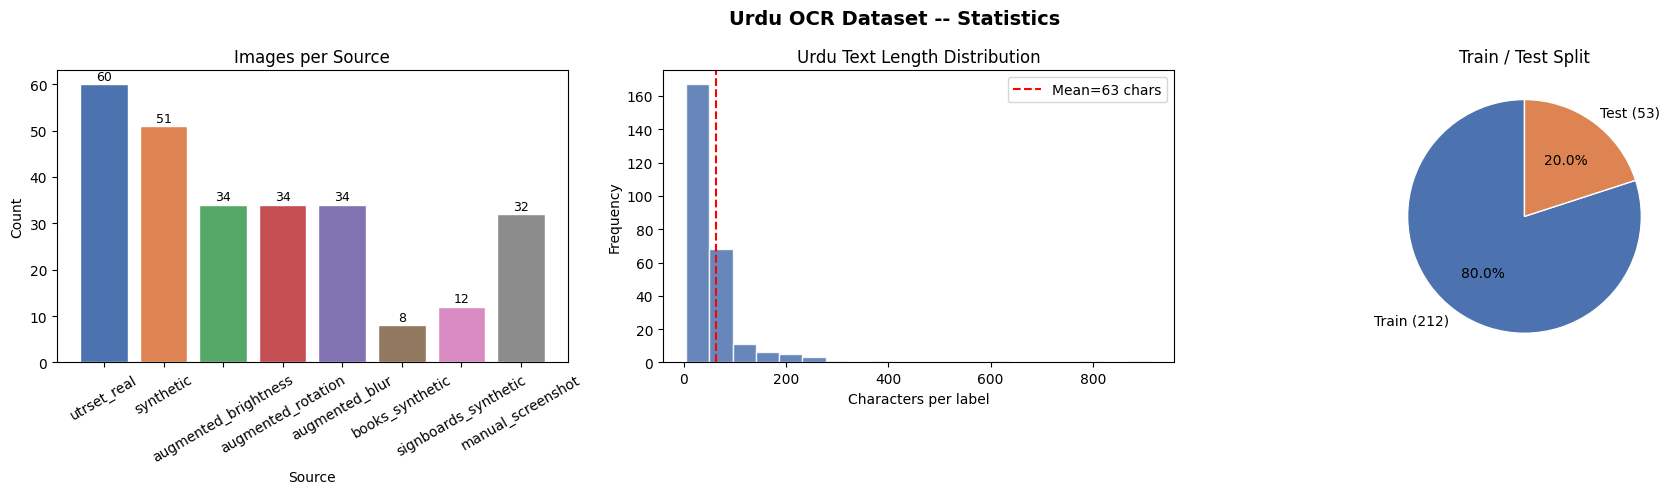

Plot saved: data/dataset_stats.png


In [26]:
def plot_dataset_stats(rows):
    """Generate three visualization plots for the dataset."""

    source_counts = {}
    for r in rows:
        src = r.get('source', 'unknown')
        source_counts[src] = source_counts.get(src, 0) + 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Urdu OCR Dataset -- Statistics", fontsize=14, fontweight='bold')

    ax = axes[0]
    sources = list(source_counts.keys())
    counts  = [source_counts[s] for s in sources]
    colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3', '#8C8C8C']
    bars    = ax.bar(sources, counts, color=colors[:len(sources)], edgecolor='white')
    ax.set_title("Images per Source")
    ax.set_xlabel("Source")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                str(cnt), ha='center', va='bottom', fontsize=9)

    ax = axes[1]
    lengths = [len(r['text']) for r in rows if r.get('text')]
    ax.hist(lengths, bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
    if lengths:
        ax.axvline(sum(lengths)/len(lengths), color='red', linestyle='--',
                   linewidth=1.5, label=f"Mean={sum(lengths)//len(lengths)} chars")
    ax.set_title("Urdu Text Length Distribution")
    ax.set_xlabel("Characters per label")
    ax.set_ylabel("Frequency")
    ax.legend()

    ax = axes[2]
    split_counts = {'train': 0, 'test': 0}
    for r in rows:
        if r.get('split') in split_counts:
            split_counts[r['split']] += 1
    ax.pie(
        split_counts.values(),
        labels=[f"Train ({split_counts['train']})", f"Test ({split_counts['test']})"],
        colors=['#4C72B0', '#DD8452'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white'}
    )
    ax.set_title("Train / Test Split")

    plt.tight_layout()
    plt.savefig("data/dataset_stats.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Plot saved: data/dataset_stats.png")

plot_dataset_stats(valid_rows)

/tmp/ipykernel_1706/2127771623.py:25: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1706/2127771623.py:25: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_1706/2127771623.py:25: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1706/2127771623.py:26: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig("data/sample_grid.png", dpi=120, bbox_inches='tight')
/tmp/ipykernel_1706/2127771623.py:26: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig("data/sample_grid.png", dpi=120, bbox_inches='tight')
/tmp/ipykernel_1706/2127771623.py:26: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig("data/sample_grid.png", dpi=120, bbox_inches='tight')
/usr/local/lib/py

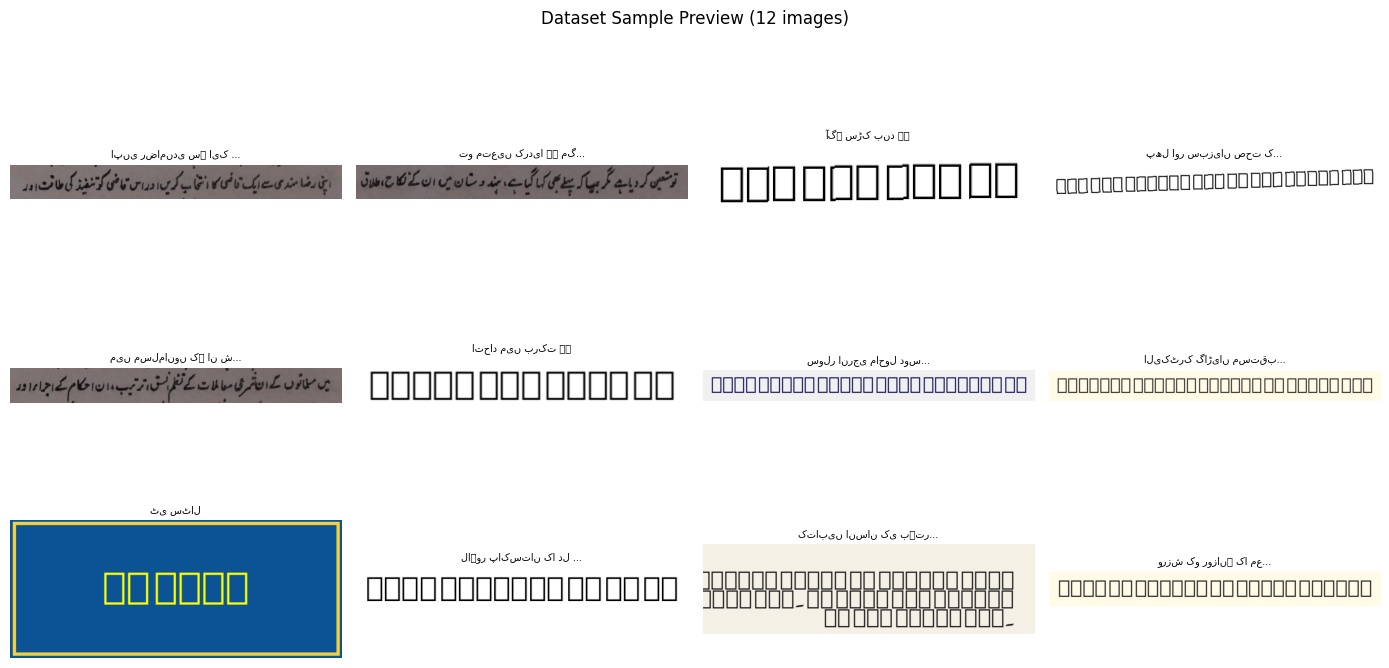

Grid saved: data/sample_grid.png


In [27]:
def plot_sample_grid(rows, n=12):
    """Show a grid of n randomly sampled images from the dataset."""
    sample = random.sample([r for r in rows if is_valid_image(r['image'])],
                           min(n, len(rows)))

    cols = 4
    rows_count = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows_count, cols,
                             figsize=(cols * 3.5, rows_count * 2.5))
    axes = axes.flatten()

    for i, row in enumerate(sample):
        img = Image.open(row['image'])
        axes[i].imshow(img, cmap='gray' if img.mode == 'L' else None)
        axes[i].set_title(
            row['text'][:20] + ('...' if len(row['text']) > 20 else ''),
            fontsize=7
        )
        axes[i].axis('off')

    for j in range(len(sample), len(axes)):
        axes[j].axis('off')

    fig.suptitle(f"Dataset Sample Preview ({len(sample)} images)", fontsize=12)
    plt.tight_layout()
    plt.savefig("data/sample_grid.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Grid saved: data/sample_grid.png")

plot_sample_grid(valid_rows, n=12)

## 13. Final Summary

In [28]:
with open(LABELS_CSV, 'r', encoding='utf-8') as f:
    all_final = list(csv.DictReader(f))

with open(TRAIN_CSV, 'r', encoding='utf-8') as f:
    train_final = list(csv.DictReader(f))

with open(TEST_CSV, 'r', encoding='utf-8') as f:
    test_final = list(csv.DictReader(f))

source_summary = {}
for r in all_final:
    src = r.get('source', 'unknown')
    source_summary[src] = source_summary.get(src, 0) + 1

print("=" * 50)
print("  URDU OCR DATASET -- FINAL SUMMARY")
print("=" * 50)
print(f"  Total labeled images : {len(all_final)}")
print(f"  Training set         : {len(train_final)}")
print(f"  Test set             : {len(test_final)}")
print()
print("  Breakdown by source:")
for src, cnt in source_summary.items():
    print(f"    {src:<25} {cnt}")
print()
print("  Output files:")
print(f"    {LABELS_CSV}")
print(f"    {TRAIN_CSV}")
print(f"    {TEST_CSV}")
print(f"    data/dataset_stats.png")
print(f"    data/sample_grid.png")
print("=" * 50)

  URDU OCR DATASET -- FINAL SUMMARY
  Total labeled images : 265
  Training set         : 212
  Test set             : 53

  Breakdown by source:
    augmented_brightness      34
    manual_screenshot         32
    synthetic                 51
    augmented_blur            34
    utrset_real               60
    augmented_rotation        34
    books_synthetic           8
    signboards_synthetic      12

  Output files:
    data/labels.csv
    data/train.csv
    data/test.csv
    data/dataset_stats.png
    data/sample_grid.png


In [29]:
# Print complete folder structure with file counts
for root, dirs, files in os.walk('data'):
    level = root.replace('data', '').count(os.sep)
    indent = '    ' * level
    folder_name = os.path.basename(root)
    file_count = len([f for f in files if f.endswith(('.png', '.jpg', '.jpeg', '.csv'))])
    print(f'{indent}[DIR] {folder_name}/ ({file_count} files)')

    if level < 2:
        subindent = '    ' * (level + 1)
        for file in files:
            if file.endswith('.csv'):
                print(f'{subindent}[FILE] {file}')

[DIR] data/ (5 files)
    [FILE] train.csv
    [FILE] test.csv
    [FILE] labels.csv
    [DIR] raw/ (0 files)
        [DIR] books/ (8 files)
        [DIR] newspaper/ (32 files)
        [DIR] signboards/ (12 files)
        [DIR] other/ (60 files)
        [DIR] synthetic/ (51 files)
        [DIR] augmented/ (102 files)
